In [42]:
import pandas as pd
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
print("Train shape:", train.shape)
print("Test shape:", test.shape)
train.head()

Train shape: (1460, 81)
Test shape: (1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [43]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [44]:
with open('data_description.txt', 'r') as f:
    content = f.read()
idx = content.find('PoolQC')
print(content[idx:idx+300])

PoolQC: Pool quality
		
       Ex	Excellent
       Gd	Good
       TA	Average/Typical
       Fa	Fair
       NA	No Pool
		
Fence: Fence quality
		
       GdPrv	Good Privacy
       MnPrv	Minimum Privacy
       GdWo	Good Wood
       MnWw	Minimum Wood/Wire
       NA	No Fence
	
MiscFeature: Miscellaneous 


In [45]:
idx = content.find('GarageType')
print(content[idx:idx+250])
print("---")
idx2 = content.find('BsmtQual')
print(content[idx2:idx2+250])

GarageType: Garage location
		
       2Types	More than one type of garage
       Attchd	Attached to home
       Basment	Basement Garage
       BuiltIn	Built-In (Garage part of house - typically has room above garage)
       CarPort	Car Port
       De
---
BsmtQual: Evaluates the height of the basement

       Ex	Excellent (100+ inches)	
       Gd	Good (90-99 inches)
       TA	Typical (80-89 inches)
       Fa	Fair (70-79 inches)
       Po	Poor (<70 inches
       NA	No Basement
		
BsmtCond: Evaluates th


In [46]:
idx = content.find('MasVnrType')
print(content[idx:idx+250])

MasVnrType: Masonry veneer type

       BrkCmn	Brick Common
       BrkFace	Brick Face
       CBlock	Cinder Block
       None	None
       Stone	Stone
	
MasVnrArea: Masonry veneer area in square feet

ExterQual: Evaluates the quality of the material on


In [47]:
print(train['SalePrice'].describe())
print()
print("Skewness:", train['SalePrice'].skew())

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

Skewness: 1.8828757597682129


In [48]:
import numpy as np
train['SalePrice_log'] = np.log1p(train['SalePrice'])
print("Original skewness:", train['SalePrice'].skew())
print("Log-transformed skewness:", train['SalePrice_log'].skew())

Original skewness: 1.8828757597682129
Log-transformed skewness: 0.12134661989685333


In [49]:
missing = train.isnull().sum().sort_values(ascending=False)
missing = missing[missing > 0]
missing_pct = (missing / len(train)) * 100
pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct.round(2)})

,Missing Count,Missing %
PoolQC,1453,99.52
MiscFeature,1406,96.30
Alley,1369,93.77
Fence,1179,80.75
MasVnrType,872,59.73
FireplaceQu,690,47.26
LotFrontage,259,17.74
GarageQual,81,5.55
GarageYrBlt,81,5.55
GarageFinish,81,5.55


In [50]:
numeric_cols = train.select_dtypes(include=['int64', 'float64']).columns
correlations = train[numeric_cols].corr()['SalePrice'].sort_values(ascending=False)
print(correlations.head(15))

SalePrice        1.000000
SalePrice_log    0.948374
OverallQual      0.790982
GrLivArea        0.708624
GarageCars       0.640409
GarageArea       0.623431
TotalBsmtSF      0.613581
1stFlrSF         0.605852
FullBath         0.560664
TotRmsAbvGrd     0.533723
YearBuilt        0.522897
YearRemodAdd     0.507101
GarageYrBlt      0.486362
MasVnrArea       0.477493
Fireplaces       0.466929
Name: SalePrice, dtype: float64


In [51]:
neighborhood_price = train.groupby('Neighborhood')['SalePrice'].median().sort_values(ascending=False)
print(neighborhood_price)

Neighborhood
NridgHt    315000.0
NoRidge    301500.0
StoneBr    278000.0
Timber     228475.0
Somerst    225500.0
Veenker    218000.0
Crawfor    200624.0
ClearCr    200250.0
CollgCr    197200.0
Blmngtn    191000.0
NWAmes     182900.0
Gilbert    181000.0
SawyerW    179900.0
Mitchel    153500.0
NPkVill    146000.0
NAmes      140000.0
SWISU      139500.0
Blueste    137500.0
Sawyer     135000.0
BrkSide    124300.0
Edwards    121750.0
OldTown    119000.0
BrDale     106000.0
IDOTRR     103000.0
MeadowV     88000.0
Name: SalePrice, dtype: float64


In [52]:
none_cols = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu', 
             'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
             'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
             'MasVnrType']
for col in none_cols:
    train[col] = train[col].fillna('None')
    test[col] = test[col].fillna('None')
print("Remaining missing in these columns (train):")
print(train[none_cols].isnull().sum().sum())

Remaining missing in these columns (train):
0


In [53]:
lotfrontage_by_neighborhood = train.groupby('Neighborhood')['LotFrontage'].median()
train['LotFrontage'] = train.apply(
    lambda row: lotfrontage_by_neighborhood[row['Neighborhood']] if pd.isnull(row['LotFrontage']) else row['LotFrontage'],
    axis=1
)
test['LotFrontage'] = test.apply(
    lambda row: lotfrontage_by_neighborhood[row['Neighborhood']] if pd.isnull(row['LotFrontage']) else row['LotFrontage'],
    axis=1
)
train['GarageYrBlt'] = train['GarageYrBlt'].fillna(0)
test['GarageYrBlt'] = test['GarageYrBlt'].fillna(0)
train['MasVnrArea'] = train['MasVnrArea'].fillna(0)
test['MasVnrArea'] = test['MasVnrArea'].fillna(0)
electrical_mode = train['Electrical'].mode()[0]
train['Electrical'] = train['Electrical'].fillna(electrical_mode)
test['Electrical'] = test['Electrical'].fillna(electrical_mode)
print("Total missing in train:", train.isnull().sum().sum())
print("Total missing in test (excluding SalePrice):", test.isnull().sum().sum())

Total missing in train: 0
Total missing in test (excluding SalePrice): 22


In [54]:
test_missing = test.isnull().sum()
test_missing = test_missing[test_missing > 0].sort_values(ascending=False)
print(test_missing)

MSZoning        4
Utilities       2
BsmtFullBath    2
BsmtHalfBath    2
Functional      2
Exterior2nd     1
Exterior1st     1
BsmtUnfSF       1
BsmtFinSF2      1
BsmtFinSF1      1
TotalBsmtSF     1
KitchenQual     1
GarageCars      1
GarageArea      1
SaleType        1
dtype: int64


In [55]:
zero_fill_cols = ['BsmtFullBath', 'BsmtHalfBath', 'BsmtUnfSF', 'BsmtFinSF2', 
                   'BsmtFinSF1', 'TotalBsmtSF', 'GarageCars', 'GarageArea']

for col in zero_fill_cols:
    test[col] = test[col].fillna(0)

mode_fill_cols = ['MSZoning', 'Utilities', 'Functional', 'Exterior2nd', 
                   'Exterior1st', 'KitchenQual', 'SaleType']

for col in mode_fill_cols:
    mode_val = train[col].mode()[0]
    test[col] = test[col].fillna(mode_val)

print("Remaining missing in test:", test.isnull().sum().sum())

Remaining missing in test: 0


In [56]:
quality_map = {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5}
quality_cols = ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'HeatingQC', 
                'KitchenQual', 'FireplaceQu', 'GarageQual', 'GarageCond', 'PoolQC']
for col in quality_cols:
    train[col] = train[col].map(quality_map)
    test[col] = test[col].map(quality_map)
print(train[quality_cols].head())

   ExterQual  ExterCond  BsmtQual  BsmtCond  HeatingQC  KitchenQual  \
0          4          3         4         3          5            4   
1          3          3         4         3          5            3   
2          4          3         4         3          5            4   
3          3          3         3         4          4            4   
4          4          3         4         3          5            4   

   FireplaceQu  GarageQual  GarageCond  PoolQC  
0            0           3           3       0  
1            3           3           3       0  
2            3           3           3       0  
3            4           3           3       0  
4            3           3           3       0  


In [57]:
train['TotalSF'] = train['TotalBsmtSF'] + train['1stFlrSF'] + train['2ndFlrSF']
test['TotalSF'] = test['TotalBsmtSF'] + test['1stFlrSF'] + test['2ndFlrSF']

train['TotalBathrooms'] = train['FullBath'] + 0.5*train['HalfBath'] + train['BsmtFullBath'] + 0.5*train['BsmtHalfBath']
test['TotalBathrooms'] = test['FullBath'] + 0.5*test['HalfBath'] + test['BsmtFullBath'] + 0.5*test['BsmtHalfBath']

train['HouseAge'] = train['YrSold'] - train['YearBuilt']
test['HouseAge'] = test['YrSold'] - test['YearBuilt']

train['YearsSinceRemodel'] = train['YrSold'] - train['YearRemodAdd']
test['YearsSinceRemodel'] = test['YrSold'] - test['YearRemodAdd']

print(train[['TotalSF', 'TotalBathrooms', 'HouseAge', 'YearsSinceRemodel']].describe())

            TotalSF  TotalBathrooms     HouseAge  YearsSinceRemodel
count   1460.000000     1460.000000  1460.000000        1460.000000
mean    2567.048630        2.210616    36.547945          22.950000
std      821.714421        0.785399    30.250152          20.640653
min      334.000000        1.000000     0.000000          -1.000000
25%     2009.500000        2.000000     8.000000           4.000000
50%     2474.000000        2.000000    35.000000          14.000000
75%     3004.000000        2.500000    54.000000          41.000000
max    11752.000000        6.000000   136.000000          60.000000


In [58]:
print(train[train['YearsSinceRemodel'] < 0][['YrSold', 'YearRemodAdd', 'YearBuilt', 'YearsSinceRemodel']])

     YrSold  YearRemodAdd  YearBuilt  YearsSinceRemodel
523    2007          2008       2007                 -1


In [59]:
train['YearsSinceRemodel'] = train['YearsSinceRemodel'].clip(lower=0)
test['YearsSinceRemodel'] = test['YearsSinceRemodel'].clip(lower=0)
print("Min YearsSinceRemodel (train):", train['YearsSinceRemodel'].min())
print("Min YearsSinceRemodel (test):", test['YearsSinceRemodel'].min())

Min YearsSinceRemodel (train): 0
Min YearsSinceRemodel (test): 0


In [60]:
new_features = ['TotalSF', 'TotalBathrooms', 'HouseAge', 'YearsSinceRemodel']
print(train[new_features + ['SalePrice']].corr()['SalePrice'])

TotalSF              0.782260
TotalBathrooms       0.631731
HouseAge            -0.523350
YearsSinceRemodel   -0.509096
SalePrice            1.000000
Name: SalePrice, dtype: float64


In [61]:
categorical_cols = train.select_dtypes(include=['object']).columns.tolist()
print("Remaining categorical columns to encode:", len(categorical_cols))
print(categorical_cols)

Remaining categorical columns to encode: 33
['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'Foundation', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'CentralAir', 'Electrical', 'Functional', 'GarageType', 'GarageFinish', 'PavedDrive', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition']


D:\Temp\ipykernel_7916\113239120.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = train.select_dtypes(include=['object']).columns.tolist()


In [62]:
train = pd.get_dummies(train, columns=categorical_cols)
test = pd.get_dummies(test, columns=categorical_cols)
print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (1460, 269)
Test shape: (1459, 251)


In [63]:
train_cols = set(train.columns) - {'SalePrice', 'SalePrice_log'}
test_cols = set(test.columns)
only_in_train = train_cols - test_cols
only_in_test = test_cols - train_cols
print("Columns only in train:", only_in_train)
print("Columns only in test:", only_in_test)

Columns only in train: {'Exterior1st_ImStucc', 'Condition2_RRNn', 'RoofMatl_Membran', 'Utilities_NoSeWa', 'RoofMatl_ClyTile', 'Condition2_RRAe', 'RoofMatl_Metal', 'Electrical_Mix', 'MiscFeature_TenC', 'RoofMatl_Roll', 'Exterior1st_Stone', 'Condition2_RRAn', 'Heating_OthW', 'HouseStyle_2.5Fin', 'Exterior2nd_Other', 'Heating_Floor'}
Columns only in test: set()


In [64]:
missing_in_test = set(train.columns) - set(test.columns) - {'SalePrice', 'SalePrice_log'}
for col in missing_in_test:
    test[col] = 0
test = test[[col for col in train.columns if col not in ['SalePrice', 'SalePrice_log']]]
print("Train shape:", train.shape)
print("Test shape:", test.shape)
train_cols_check = set(train.columns) - {'SalePrice', 'SalePrice_log'}
test_cols_check = set(test.columns)
print("Mismatch remaining:", train_cols_check - test_cols_check, test_cols_check - train_cols_check)

Train shape: (1460, 269)
Test shape: (1459, 267)
Mismatch remaining: set() set()


In [65]:
from sklearn.model_selection import train_test_split
feature_cols = [col for col in train.columns if col not in ['SalePrice', 'SalePrice_log', 'Id']]
X = train[feature_cols]
y = train['SalePrice_log']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)

X_train shape: (1168, 266)
X_val shape: (292, 266)


In [66]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
import numpy as np
ridge = Ridge(alpha=10, random_state=42)
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_val)
rmse_ridge = np.sqrt(mean_squared_error(y_val, y_pred_ridge))
print("Ridge Validation RMSE (log scale):", rmse_ridge)

Ridge Validation RMSE (log scale): 0.13275005879227741


In [67]:
from sklearn.model_selection import cross_val_score, KFold
cv = KFold(n_splits=5, shuffle=True, random_state=42)
ridge_cv_scores = -cross_val_score(ridge, X_train, y_train, cv=cv, scoring='neg_root_mean_squared_error')
print("Ridge CV RMSE scores:", ridge_cv_scores)
print("Ridge CV Mean RMSE:", ridge_cv_scores.mean())
print("Ridge CV Std RMSE:", ridge_cv_scores.std())

Ridge CV RMSE scores: [0.13383383 0.14059506 0.19938816 0.12007177 0.1198549 ]
Ridge CV Mean RMSE: 0.14274874534307191
Ridge CV Std RMSE: 0.029429615373506694


In [68]:
print(train['SalePrice'].sort_values(ascending=False).head(10))
print()
print(train[['GrLivArea', 'SalePrice']].sort_values('GrLivArea', ascending=False).head(5))

691     755000
1182    745000
1169    625000
898     611657
803     582933
1046    556581
440     555000
769     538000
178     501837
798     485000
Name: SalePrice, dtype: int64

      GrLivArea  SalePrice
1298       5642     160000
523        4676     184750
1182       4476     745000
691        4316     755000
1169       3627     625000


In [69]:
outlier_condition = (train['GrLivArea'] > 4000) & (train['SalePrice'] < 300000)
print("Outliers found:", train[outlier_condition].shape[0])
print(train[outlier_condition][['GrLivArea', 'SalePrice']])
train = train[~outlier_condition].reset_index(drop=True)
print("New train shape:", train.shape)

Outliers found: 2
      GrLivArea  SalePrice
523        4676     184750
1298       5642     160000
New train shape: (1458, 269)


In [70]:
X = train[feature_cols]
y = train['SalePrice_log']
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
ridge_cv_scores = -cross_val_score(ridge, X_train, y_train, cv=cv, scoring='neg_root_mean_squared_error')
print("Ridge CV RMSE scores:", ridge_cv_scores)
print("Ridge CV Mean RMSE:", ridge_cv_scores.mean())
print("Ridge CV Std RMSE:", ridge_cv_scores.std())

Ridge CV RMSE scores: [0.12872056 0.10419448 0.10194257 0.11092099 0.11963723]
Ridge CV Mean RMSE: 0.11308316678730974
Ridge CV Std RMSE: 0.009952692956418268


In [71]:
from xgboost import XGBRegressor
xgb_reg = XGBRegressor(random_state=42)
xgb_cv_scores = -cross_val_score(xgb_reg, X_train, y_train, cv=cv, scoring='neg_root_mean_squared_error')
print("XGBoost CV RMSE scores:", xgb_cv_scores)
print("XGBoost CV Mean RMSE:", xgb_cv_scores.mean())
print("XGBoost CV Std RMSE:", xgb_cv_scores.std())

XGBoost CV RMSE scores: [0.1573517  0.13607661 0.12346861 0.12542336 0.13415602]
XGBoost CV Mean RMSE: 0.13529526187955265
XGBoost CV Std RMSE: 0.012047564223639444


In [72]:
from sklearn.linear_model import Lasso
lasso = Lasso(alpha=0.001, random_state=42, max_iter=5000)
lasso_cv_scores = -cross_val_score(lasso, X_train, y_train, cv=cv, scoring='neg_root_mean_squared_error')
print("Lasso CV Mean RMSE:", lasso_cv_scores.mean())
print("Lasso CV Std RMSE:", lasso_cv_scores.std())

d:\Payoda_ML\ML-Assignment\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.623414e-02, tolerance: 1.377e-02
  model = cd_fast.enet_coordinate_descent(
d:\Payoda_ML\ML-Assignment\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.144192e-02, tolerance: 1.462e-02
  model = cd_fast.enet_coordinate_descent(


Lasso CV Mean RMSE: 0.11466649235994864
Lasso CV Std RMSE: 0.009817692206522755


In [73]:
from sklearn.preprocessing import StandardScaler
numeric_features = ['LotFrontage', 'LotArea', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea',
                     'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', 
                     '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'GarageYrBlt', 'GarageArea',
                     'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch',
                     'PoolArea', 'MiscVal', 'TotalSF', 'HouseAge', 'YearsSinceRemodel']
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_val_scaled = X_val.copy()
X_train_scaled[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_val_scaled[numeric_features] = scaler.transform(X_val[numeric_features])

ridge_scaled_cv = -cross_val_score(ridge, X_train_scaled, y_train, cv=cv, scoring='neg_root_mean_squared_error')
lasso_scaled_cv = -cross_val_score(lasso, X_train_scaled, y_train, cv=cv, scoring='neg_root_mean_squared_error')

print("Ridge (scaled) CV Mean RMSE:", ridge_scaled_cv.mean())
print("Lasso (scaled) CV Mean RMSE:", lasso_scaled_cv.mean())

Ridge (scaled) CV Mean RMSE: 0.11299476169856318
Lasso (scaled) CV Mean RMSE: 0.1139537398563727


In [74]:
from sklearn.model_selection import RandomizedSearchCV
param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [2, 3, 4, 5],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'subsample': [0.6, 0.7, 0.8, 0.9],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9]
}

random_search_xgb = RandomizedSearchCV(
    XGBRegressor(random_state=42),
    param_distributions=param_dist,
    n_iter=30,
    cv=cv,
    scoring='neg_root_mean_squared_error',
    random_state=42,
    n_jobs=-1
)

random_search_xgb.fit(X_train, y_train)

print("Best params:", random_search_xgb.best_params_)
print("Best CV RMSE:", -random_search_xgb.best_score_)

Best params: {'subsample': 0.7, 'n_estimators': 500, 'max_depth': 2, 'learning_rate': 0.05, 'colsample_bytree': 0.8}
Best CV RMSE: 0.11508632475894928


In [75]:
ridge.fit(X_train_scaled, y_train)
best_xgb_reg = random_search_xgb.best_estimator_
best_xgb_reg.fit(X_train, y_train)
ridge_val_pred = ridge.predict(X_val_scaled)
xgb_val_pred = best_xgb_reg.predict(X_val)
blend_pred = 0.7 * ridge_val_pred + 0.3 * xgb_val_pred
blend_rmse = np.sqrt(mean_squared_error(y_val, blend_pred))
ridge_rmse = np.sqrt(mean_squared_error(y_val, ridge_val_pred))
xgb_rmse = np.sqrt(mean_squared_error(y_val, xgb_val_pred))
print("Ridge alone Validation RMSE:", ridge_rmse)
print("XGBoost alone Validation RMSE:", xgb_rmse)
print("Blend (70% Ridge + 30% XGBoost) Validation RMSE:", blend_rmse)

Ridge alone Validation RMSE: 0.12205985727026389
XGBoost alone Validation RMSE: 0.11353484417729713
Blend (70% Ridge + 30% XGBoost) Validation RMSE: 0.11593086943044643


In [76]:
from sklearn.metrics import mean_absolute_error, r2_score
blend_pred_dollars = np.expm1(blend_pred)
y_val_dollars = np.expm1(y_val)
mae_dollars = mean_absolute_error(y_val_dollars, blend_pred_dollars)
r2 = r2_score(y_val, blend_pred)
print("Validation RMSLE (log scale):", blend_rmse)
print("MAE (in $):", mae_dollars)
print("R^2:", r2)

Validation RMSLE (log scale): 0.11593086943044643
MAE (in $): 13848.991831751531
R^2: 0.9202736721270877


In [77]:
test_features = test[feature_cols].copy()
test_features[numeric_features] = scaler_final.transform(test[numeric_features])

ridge_test_pred = ridge.predict(test_features)
xgb_test_pred = best_xgb_reg.predict(test[feature_cols])

blend_test_pred_log = 0.7 * ridge_test_pred + 0.3 * xgb_test_pred
blend_test_pred = np.expm1(blend_test_pred_log)

submission = pd.DataFrame({
    'Id': test['Id'],
    'SalePrice': blend_test_pred
})

submission.to_csv('submission.csv', index=False)
submission.head()

,Id,SalePrice
0,1461,115568.579158
1,1462,155671.222632
2,1463,179439.207635
3,1464,194471.799274
4,1465,189800.743830


In [78]:
importance_df_p2 = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': best_xgb_reg.feature_importances_
}).sort_values('Importance', ascending=False)

print(importance_df_p2.head(15).to_string(index=False))

       Feature  Importance
     ExterQual    0.335346
   OverallQual    0.088558
       TotalSF    0.080900
    GarageCars    0.048015
   KitchenQual    0.039026
  CentralAir_Y    0.030915
    GarageCond    0.027485
TotalBathrooms    0.026074
   FireplaceQu    0.025584
    Fireplaces    0.025424
      BsmtQual    0.020107
      HouseAge    0.017214
   MSZoning_RL    0.016699
  CentralAir_N    0.012654
   MSZoning_RM    0.012290


In [80]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

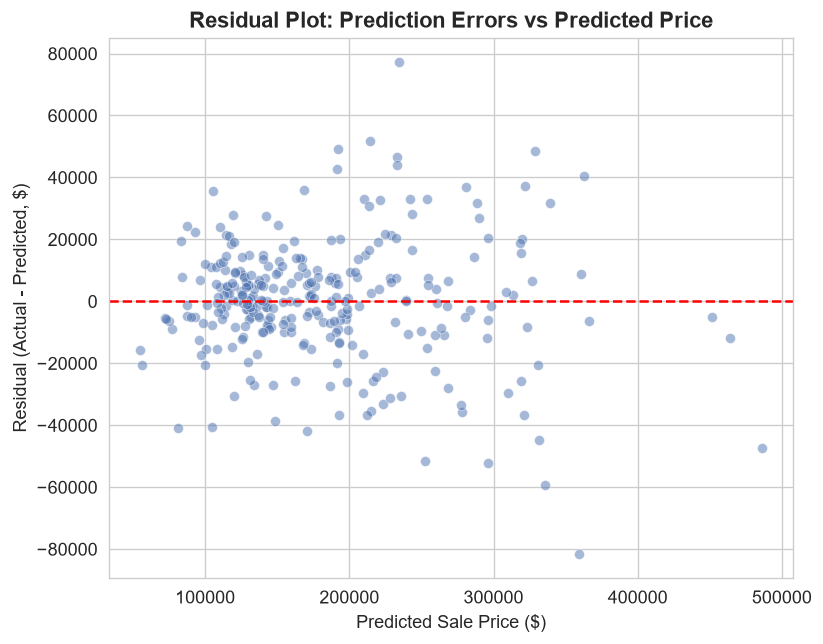

In [81]:
plt.figure(figsize=(7, 5.5))

residuals = y_val_dollars - blend_pred_dollars

ax = sns.scatterplot(x=blend_pred_dollars, y=residuals, alpha=0.5, color='#4C72B0')
ax.axhline(y=0, color='red', linestyle='--', linewidth=1.5)

ax.set_xlabel('Predicted Sale Price ($)')
ax.set_ylabel('Residual (Actual - Predicted, $)')
ax.set_title('Residual Plot: Prediction Errors vs Predicted Price', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('plot1_residuals.png', dpi=150, bbox_inches='tight')
plt.show()

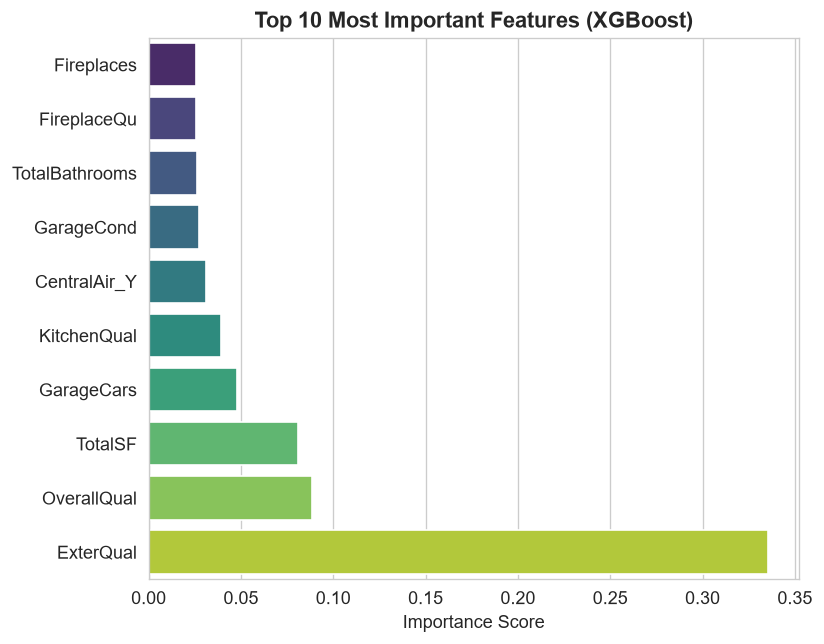

In [ ]:
plt.figure(figsize=(7, 5.5))
top_features_p2 = importance_df_p2.head(10).sort_values('Importance', ascending=True)
ax = sns.barplot(data=top_features_p2, x='Importance', y='Feature', hue='Feature', palette='viridis', legend=False)
ax.set_xlabel('Importance Score')
ax.set_ylabel('')
ax.set_title('Top 10 Most Important Features (XGBoost)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot2_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

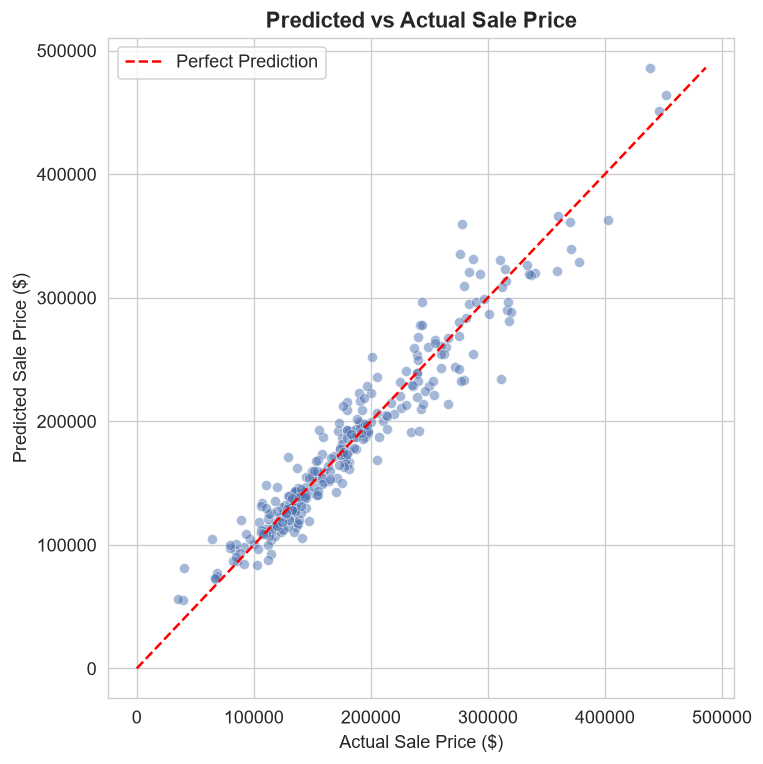

In [83]:
plt.figure(figsize=(6.5, 6.5))
ax = sns.scatterplot(x=y_val_dollars, y=blend_pred_dollars, alpha=0.5, color='#4C72B0')
max_val = max(y_val_dollars.max(), blend_pred_dollars.max())
ax.plot([0, max_val], [0, max_val], color='red', linestyle='--', linewidth=1.5, label='Perfect Prediction')
ax.set_xlabel('Actual Sale Price ($)')
ax.set_ylabel('Predicted Sale Price ($)')
ax.set_title('Predicted vs Actual Sale Price', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('plot3_predicted_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()